## 1. Load files

In [1]:
import warnings
warnings.filterwarnings("ignore")

from langchain_community.document_loaders import TextLoader
from langchain_core.documents import Document
from pathlib import Path

DATA_DIR = "docs"

all_docs = []
for txt_file in sorted(Path(DATA_DIR).glob("*.txt")):
    loader = TextLoader(str(txt_file), encoding="utf-8")
    docs = loader.load()
    
    for doc in docs:
        lines = doc.page_content.splitlines()
        url = lines[0].strip() if lines else ""
        content = "\n".join(lines[1:]).strip()
        
        stem = txt_file.stem  # removes .txt
        page_title = ".".join(stem.split(".")[1:])  
        
        all_docs.append(Document(
            page_content=content,
            metadata={
                "source": txt_file.name,
                "url": url,
                "page_title": page_title
            }
        ))

print(f"Total files loaded : {len(all_docs)}")
print(f"Total characters   : {sum(len(d.page_content) for d in all_docs):,}")
print(f"\nSample metadata    : {all_docs[0].metadata}")
print(f"First 300 chars    :\n{all_docs[0].page_content[:300]}")

Total files loaded : 9
Total characters   : 30,225

Sample metadata    : {'source': '1.netsoltech.com.txt', 'url': 'https://netsoltech.com/', 'page_title': 'netsoltech.com'}
First 300 chars    :
Shaping Smarter Finance
AI-enabled ecosystems
that make commerce
secure
We remove complexity from the asset lifecycle with a composable platform that integrates effortlessly.
The world's leading brands are powered by NETSOL
Transcend Platform
An AI-driven, composable platform for lenders, OEMs, deal


## 2. Chunking

In [2]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(
    chunk_size=800,
    chunk_overlap=75,
    separators=["\n\n", "\n", ". ", " ", ""],
    length_function=len,
)

chunks = splitter.split_documents(all_docs)

print(f"Total documents    : {len(all_docs)}")
print(f"Total chunks       : {len(chunks)}")
sizes = [len(c.page_content) for c in chunks]
print(f"Avg chunk size     : {sum(sizes)//len(sizes)} chars")
print(f"Min / Max          : {min(sizes)} / {max(sizes)} chars")
print(f"\nSample chunk metadata : {chunks[0].metadata}")
print(f"\nChunk 0 preview:\n{chunks[0].page_content}")

Total documents    : 9
Total chunks       : 49
Avg chunk size     : 646 chars
Min / Max          : 83 / 798 chars

Sample chunk metadata : {'source': '1.netsoltech.com.txt', 'url': 'https://netsoltech.com/', 'page_title': 'netsoltech.com'}

Chunk 0 preview:
Shaping Smarter Finance
AI-enabled ecosystems
that make commerce
secure
We remove complexity from the asset lifecycle with a composable platform that integrates effortlessly.
The world's leading brands are powered by NETSOL
Transcend Platform
An AI-driven, composable platform for lenders, OEMs, dealers and fleets uniting digital retail, asset finance, and loan servicing with trust and transparency.
Digital Retail
Finance
AI Labs
Marketplace
Consultancy
Transcend Retail
End-to-end orchestration for OEMs and dealers. Modular and scalable to unify showroom and online journeys into one seamless retail experience.
Auto retail redefined. Personalized paths, connected touchpoints and AI-driven precision.
OEMs
Independent dealers
Dealer gro

## 3. Ebedding & Vector Store

In [4]:
from langchain_openai import OpenAIEmbeddings
from dotenv import load_dotenv
load_dotenv(override=True)
embeddings = OpenAIEmbeddings(
    model="text-embedding-3-small",
)

In [5]:
vec = embeddings.embed_query("hello")
print(len(vec))

1536


In [7]:

from langchain_community.vectorstores import FAISS
vectorstore = FAISS.from_documents(
    documents=chunks,
    embedding=embeddings
)

print(f"Vectorstore created successfully")
print(f"Total vectors stored: {vectorstore.index.ntotal}")

Vectorstore created successfully
Total vectors stored: 49


In [8]:
query = "Who is ceo of netsole?"
results = vectorstore.similarity_search(query, k=3)
print(f"\nTest query: '{query}'")
for i, doc in enumerate(results):
    print(f"\n--- Result {i+1} ---")
    print(f"Source : {doc.metadata['source']}")
    print(f"URL    : {doc.metadata['url']}")
    print(f"Preview: {doc.page_content[:200]}")


Test query: 'Who is ceo of netsole?'

--- Result 1 ---
Source : 5.about-us_management-team.txt
URL    : https://netsoltech.com/about-us/management-team
Preview: Management Team
Blending decades of global experience across technology, finance, and operations to fuel growth and innovation.
Najeeb Ghauri
Founder, Chairman &
Chief Executive Officer,
NETSOL Techno

--- Result 2 ---
Source : 2.about-us_board-of-directors.txt
URL    : https://netsoltech.com/about-us/board-of-directors
Preview: Board of Directors
Visionary governance rooted in real-world experience
Najeeb Ghauri
Director, Chief Executive Officer and Chair of the Board, NetSol Technologies, Inc
View Profile
Syed Kausar Kazmi


--- Result 3 ---
Source : 5.about-us_management-team.txt
URL    : https://netsoltech.com/about-us/management-team
Preview: Asad Ghauri
Global Head of Sales & GMD, NETSOL Technologies, Inc.
Umar Qadri
Deputy Global Head of Sales, NETSOL Technologies Inc.
Faizaan Ghauri
Chief Strategy Officer, NETSOL Techn

In [9]:
vectorstore.save_local("my_faiss_db")

## 4. Visualization

In [10]:
faiss_index = vectorstore.index

vectors = faiss_index.reconstruct_n(
    0,
    faiss_index.ntotal
)

print(vectors.shape)

(49, 1536)


In [11]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
points = pca.fit_transform(vectors)

print(points.shape)

(49, 2)


In [14]:
docstore = vectorstore.docstore._dict
index_to_docstore_id = vectorstore.index_to_docstore_id

labels = [
    docstore[index_to_docstore_id[i]].metadata.get("source", "unknown")
    for i in range(vectorstore.index.ntotal)
]

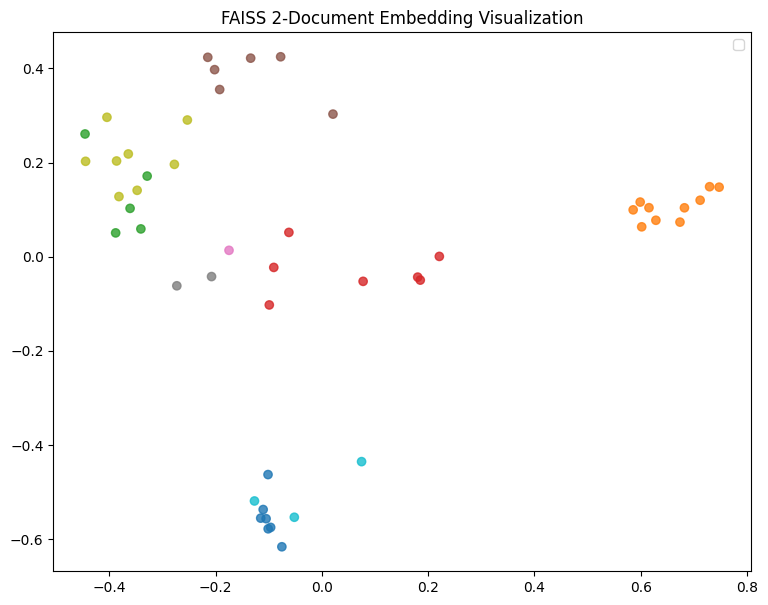

In [16]:
import numpy as np
import matplotlib.pyplot as plt

unique_labels = list(set(labels))
color_map = {label: i for i, label in enumerate(unique_labels)}

colors = np.array([color_map[l] for l in labels])

plt.figure(figsize=(9, 7))

plt.scatter(
    points[:, 0],
    points[:, 1],
    c=colors,
    cmap="tab10",
    alpha=0.8
)
plt.legend()
plt.title("FAISS 2-Document Embedding Visualization")
plt.show()